## 5 (revised). RQ5 — Classifier false negatives: full origin + per-layer NK signals

Returns TextUnits where the classifier predicts **label=0** (no NK) but
≥ 2 independent linguistic layers disagree.

**Columns returned**

| Column | Content |
| --- | --- |
| `tu_id`, `text`, `position` | TextUnit identity |
| `tu_created_at` | TextUnit creation timestamp |
| `clf_confidence` | Classifier confidence on label=0 |
| `layer_count` | How many linguistic layers fired |
| `repo` | Repository full name |
| `parent_type` | Issue \| PullRequest \| Commit \| Comment |
| `parent_ref` | Issue/PR number, or first 8 chars of commit SHA |
| `author` | GitHub login of artefact author |
| `text_role` | title \| body \| commit_message \| comment_body |
| `lexical_markers` | List of `{rule_id, surface, lemma, category, polarity}` |
| `morph_signals` | List of `{category, subcategory, rule_id, surface}` |
| `word_formation_signals` | List of `{category, subcategory, rule_id, surface}` |
| `rhetorical_signals` | List of `{figure_id, family, subtype, surface}` |
| `n_lex`, `n_morph`, `n_wf`, `n_rhet` | Per-layer signal counts |

> **Cross-product note.** Multiple `OPTIONAL MATCH` clauses for different signal
> layers would multiply row counts before `collect()`. This query uses one
> `CALL {}` subquery per layer to keep the collections independent.

> **Comment parents.** `repo` is null when the TextUnit's parent is a `Comment`
> (Comments are not directly CONTAINED by a Repository). Filter with
> `df[df.repo.notna()]` if you want artefact-level units only.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve().parent))

from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from settings import settings

driver = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password)
)

def q(cypher, **params):
    """Run a Cypher query and return a DataFrame."""
    with driver.session() as s:
        result = s.run(cypher, **params)
        return pd.DataFrame([r.data() for r in result])

print('Connected to Neo4j.')

Connected to Neo4j.


## 1. Node counts per label

Sanity check: are all layers populated?

In [2]:
df_nodes = q("""
    CALL apoc.meta.stats()
    YIELD labels
    UNWIND keys(labels) AS label
    RETURN label, labels[label] AS count
    ORDER BY count DESC
""")
df_nodes.style.background_gradient(subset=['count'], cmap='Blues')

,label,count
0,Signal,4317
1,TextUnit,2463
2,ClassifierVerdict,2358
3,Commit,2014
4,PullRequest,124
5,Actor,93
6,Issue,3
7,Repository,1
8,RhetoricalFigure,1


CALL db.labels();              // what node types exist?
CALL db.relationshipTypes();   // what relationship types exist?
CALL db.schema.visualization();// draw the schema (Browser only)
MATCH (n) WHERE n.sandbox RETURN labels(n)[0] AS label, count(*) AS n ORDER BY n DESC;

In [3]:
df_0 = q("""
    MATCH (s:Signal)
    RETURN s.rule_id AS rule_id, s.rule_version AS version, count(*) AS n
    ORDER BY n DESC
""")

df_0.head()

,rule_id,version,n
0,clf.roberta_binary,roberta-non-knowledge-v8-base,2358
1,morph.syn.embedded_question,0.2,531
2,morph.neg.bare_modifier,0.2,404
3,morph.mod.underspecified_cancould,0.2,187
4,morph.mod.epistemic_will_predict,0.2,163


In [4]:
df_0.head(10)

,rule_id,version,n
0,clf.roberta_binary,roberta-non-knowledge-v8-base,2358
1,morph.syn.embedded_question,0.2,531
2,morph.neg.bare_modifier,0.2,404
3,morph.mod.underspecified_cancould,0.2,187
4,morph.mod.epistemic_will_predict,0.2,163
5,morph.syn.adversative,0.2,122
6,morph.mod.deontic,0.2,101
7,affix.prefix.un,0.2,73
8,morph.syn.question_mark,0.2,61
9,affix.prefix.in,0.2,48


In [5]:
# (r:Repository)-[:CONTAINS]->(i:Issue)-[:HAS_TEXT]->
df_traversal = q("""
    MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal)
    RETURN u.text, s.layer, s.category, s.subcategory, s.surface_form, s.span_start, s.span_end
""")

df_traversal.head()

,u.text,s.layer,s.category,s.subcategory,s.surface_form,s.span_start,s.span_end
0,Correct license name: ASL 2.0->Apache-2.0,classifier,roberta_binary,NaN,,0,41
1,Apache-2.0 is the SPDX compatible name. ASL is...,classifier,roberta_binary,NaN,,0,226
2,CI: Fix Typo: vanagon->ezbake,classifier,roberta_binary,NaN,,0,29
3,Standardize on CrashOnOutOfMemoryError,classifier,roberta_binary,NaN,,0,38
4,CI: Pin external actions,classifier,roberta_binary,NaN,,0,24


In [6]:
df_traversal["s.layer"].value_counts()

s.layer
classifier          2358
morpho_syntactic    1781
word_formation       169
rhetorical             9
Name: count, dtype: int64

In [7]:
df_traversal[["s.layer", "s.category"]].value_counts()

s.layer           s.category       
classifier        roberta_binary       2358
morpho_syntactic  syntactic_pattern     745
                  modality              484
                  negation              441
word_formation    affix_negation        169
morpho_syntactic  hedging                51
                  evidential             37
                  epistemic_verb         15
rhetorical        comparison              9
morpho_syntactic  tense                   8
Name: count, dtype: int64

In [8]:
df_traversal[["s.layer", "s.category", "s.subcategory"]].value_counts()

s.layer           s.category         s.subcategory       
morpho_syntactic  syntactic_pattern  embedded_question       531
                  negation           bare_negation           404
                  modality           underspecified          187
                                     epistemic_prediction    163
                  syntactic_pattern  adversative             122
                  modality           deontic                 101
word_formation    affix_negation     un_prefix                73
morpho_syntactic  syntactic_pattern  question_mark            61
word_formation    affix_negation     in_prefix                48
morpho_syntactic  evidential         inferential              37
                  negation           quantifier_no            33
                  modality           epistemic                33
                  syntactic_pattern  question_answer          30
                  hedging            plausibility_shield      27
                                

## 2. Signal counts per layer × category (heatmap)

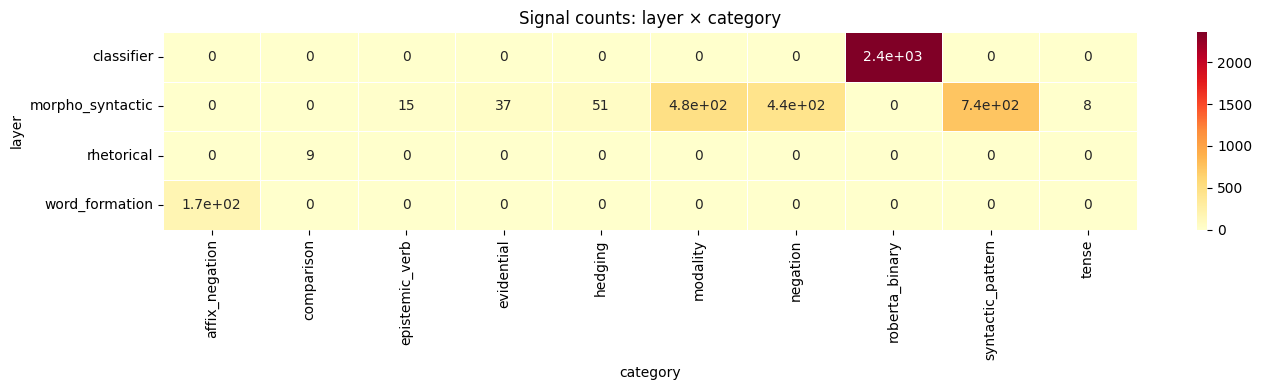

Total signals: 4,317


In [9]:
df_signals = q("""
    MATCH (s:Signal)
    RETURN s.layer AS layer, s.category AS category, count(*) AS n
    ORDER BY layer, n DESC
""")

if df_signals.empty:
    print('No signals yet — run the pipeline first.')
else:
    pivot = df_signals.pivot_table(index='layer', columns='category', values='n', fill_value=0)
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(pivot, annot=True,  cmap='YlOrRd', ax=ax, linewidths=.5)
    ax.set_title('Signal counts: layer × category')
    plt.tight_layout()
    plt.show()
    print(f'Total signals: {df_signals.n.sum():,}')

## 3. Top lexical markers (RQ1)

Which NK lexemes recur most in the corpus?

In [10]:
df_markers = q("""
    MATCH (s:Signal)-[:MATCHES_MARKER]->(m:LexicalMarker)
    RETURN m.lemma AS lemma, m.category AS category,
           m.polarity AS polarity, count(s) AS occurrences
    ORDER BY occurrences DESC
""")
df_markers

Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `MATCHES_MARKER` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=24, offset=24>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 24, 'line': 2, 'column': 24}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (s:Signal)-[:MATCHES_MARKER]->(m:LexicalMarker)\n    RETURN m.lemma AS lemma, m.category AS category,\n           m.polarity AS polarity, count(s) AS occurrences\n    ORDER BY occurrences DESC\n'
Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_de

""


In [11]:
df_markers = q("""
    MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal)-[:MATCHES_MARKER]->(m:LexicalMarker)
    MATCH (u)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
    WITH m.lemma AS lemma, m.category AS category, m.polarity AS polarity,
        u, s, v
    RETURN lemma, category, polarity,
        count(DISTINCT u) AS text_units,
        count(s) AS occurrences,
        count(DISTINCT CASE WHEN v.label = 0 THEN v END) AS label_0,
        count(DISTINCT CASE WHEN v.label = 1 THEN v END) AS label_1
    ORDER BY occurrences DESC
""")
df_markers

Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `MATCHES_MARKER` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=52, offset=52>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 52, 'line': 2, 'column': 52}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s:Signal)-[:MATCHES_MARKER]->(m:LexicalMarker)\n    MATCH (u)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)\n    WITH m.lemma AS lemma, m.category AS category, m.polarity AS polarity,\n        u, s, v\n    RETURN lemma, category, polarity,\n        count(DIST

""


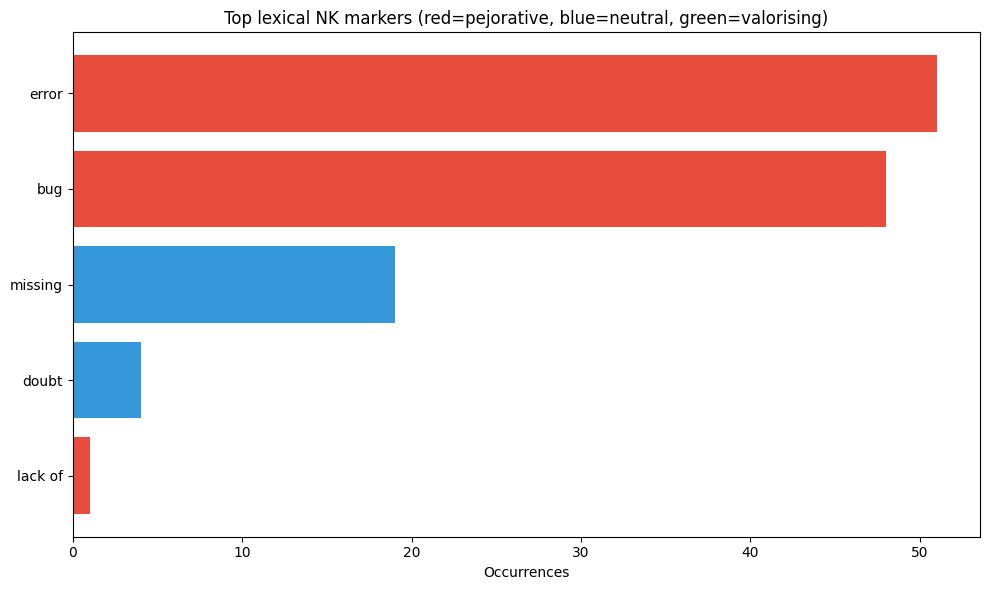

In [37]:
if not df_markers.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = df_markers['polarity'].map({
        'pejorative': '#e74c3c', 'neutral': '#3498db', 'valorising': '#2ecc71'
    }).fillna('#95a5a6')
    ax.barh(df_markers['lemma'], df_markers['occurrences'], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel('Occurrences')
    ax.set_title('Top lexical NK markers (red=pejorative, blue=neutral, green=valorising)')
    plt.tight_layout()
    plt.show()

In [12]:
CYPHER_RQ5 = """
// RQ5 — Classifier false negatives
// TextUnits: classifier label=0 AND >= $min_layers linguistic layers firing.

MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict {label: 0})
MATCH (u)-[:HAS_SIGNAL]->(s_filter:Signal)
WHERE s_filter.layer IN ['lexical','morpho_syntactic','word_formation','rhetorical']
WITH u, v, count(DISTINCT s_filter.layer) AS layer_count
WHERE layer_count >= $min_layers

// ── Origin ────────────────────────────────────────────────────────────────
MATCH (parent)-[ht:HAS_TEXT]->(u)
OPTIONAL MATCH (repo:Repository)-[:CONTAINS]->(parent)
OPTIONAL MATCH (actor:Actor)-[:AUTHORED]->(parent)

// ── NK signals per layer (CALL {} avoids cross-product) ───────────────────
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sl:Signal {layer: 'lexical'})
    OPTIONAL MATCH (sl)-[:MATCHES_MARKER]->(m:LexicalMarker)
    RETURN collect(DISTINCT {
        rule_id:  sl.rule_id,
        surface:  sl.surface_form,
        lemma:    m.lemma,
        category: m.category,
        polarity: m.polarity
    }) AS lexical_markers
}
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sm:Signal {layer: 'morpho_syntactic'})
    RETURN collect(DISTINCT {
        category:    sm.category,
        subcategory: sm.subcategory,
        rule_id:     sm.rule_id,
        surface:     sm.surface_form
    }) AS morph_signals
}
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sw:Signal {layer: 'word_formation'})
    RETURN collect(DISTINCT {
        category:    sw.category,
        subcategory: sw.subcategory,
        rule_id:     sw.rule_id,
        surface:     sw.surface_form
    }) AS word_formation_signals
}
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sr:Signal {layer: 'rhetorical'})
    OPTIONAL MATCH (sr)-[:INSTANTIATES]->(f:RhetoricalFigure)
    RETURN collect(DISTINCT {
        figure_id: f.figure_id,
        family:    f.family,
        subtype:   f.subtype,
        surface:   sr.surface_form
    }) AS rhetorical_signals
}

RETURN
    // Identity
    u.id              AS tu_id,
    u.text            AS text,
    u.position        AS position,
    u.created_at      AS tu_created_at,

    // Classifier
    v.confidence      AS clf_confidence,
    layer_count,

    // Origin
    coalesce(repo.full_name, '(comment)')  AS repo,
    labels(parent)[0]                      AS parent_type,
    CASE labels(parent)[0]
        WHEN 'Issue'       THEN toString(parent.number)
        WHEN 'PullRequest' THEN toString(parent.number)
        WHEN 'Commit'      THEN left(parent.sha, 8)
        ELSE null
    END                                    AS parent_ref,
    actor.login                            AS author,
    ht.role                                AS text_role,

    // NK signals — each layer in its own column
    lexical_markers,
    morph_signals,
    word_formation_signals,
    rhetorical_signals,

    // Flat counts for quick filtering
    size(lexical_markers)        AS n_lex,
    size(morph_signals)          AS n_morph,
    size(word_formation_signals) AS n_wf,
    size(rhetorical_signals)     AS n_rhet

ORDER BY layer_count DESC, clf_confidence DESC
LIMIT $limit
"""

df_fn = q(CYPHER_RQ5, min_layers=2, limit=50)
print(f"False negatives found: {len(df_fn)}")
df_fn[[
    'repo', 'parent_type', 'parent_ref', 'author', 'text_role',
    'tu_created_at', 'position', 'clf_confidence', 'layer_count',
    'n_lex', 'n_morph', 'n_wf', 'n_rhet', 'text'
]].head(20)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (u) { ... }', position=<SummaryInputPosition line=29, column=1, offset=1059>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1059, 'line': 29, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n// RQ5 — Classifier false negatives\n// TextUnits: classifier label=0 AND >= $min_layers linguistic layers firing.\n\nMATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict {label: 0})\nMATCH (u)-[:HAS_SIGNAL]->(s_filter:Signal)\nWHERE s_filter.layer IN ['lexical','morpho_syntactic','word_formation','rhetorical']\nWITH u, v, count(

False negatives found: 50


,repo,parent_type,parent_ref,author,text_role,tu_created_at,position,clf_confidence,layer_count,n_lex,n_morph,n_wf,n_rhet,text
0,OpenVoxProject/ezbake,Commit,68347edd,NaN,commit_message,2014-04-10T18:32:23Z,0,1.000000,2,1,1,1,1,(maint) Add stage method to allow easier invoc...
1,OpenVoxProject/ezbake,Commit,a8578c1d,NaN,commit_message,2015-01-13T19:29:45Z,0,1.000000,2,1,2,1,1,(EZ-15) lein-ezbake code cleanup.\n\nThis is i...
2,OpenVoxProject/ezbake,PullRequest,106,bastelfreak,body,2026-06-04T15:00:59Z,1,1.000000,2,1,3,1,1,We support/test against Java 21 and 25 in our ...
3,OpenVoxProject/ezbake,Commit,418bb3a2,NaN,commit_message,2014-04-10T18:18:29Z,0,1.000000,2,1,1,1,1,(PE-3516) Remove unneccessary cleanup from pos...
4,OpenVoxProject/ezbake,Commit,5b461335,NaN,commit_message,2015-04-13T17:26:02Z,0,1.000000,2,1,2,1,1,(RE-3976) Add 'Should-Start' headers to SUSE i...
5,OpenVoxProject/ezbake,Commit,7339a1a1,nmburgan,commit_message,2026-05-12T14:15:36Z,0,1.000000,2,1,1,1,1,Remove use of deprecated bundler flags\n\nIn R...
6,OpenVoxProject/ezbake,Commit,8ced0be9,NaN,commit_message,2018-11-28T18:18:06Z,0,1.000000,2,1,3,1,1,(EZ-127) Add docker-build to build an image fr...
7,OpenVoxProject/ezbake,Commit,570838bb,NaN,commit_message,2015-08-11T14:14:21Z,0,1.000000,2,1,1,1,1,(maint) Fix unterminated 'if' in RPM spec temp...
8,OpenVoxProject/ezbake,Commit,11ed95e4,NaN,commit_message,2016-09-29T23:40:11Z,0,0.996094,2,1,3,1,1,(MAINT) Set umask to 027 in cli app script\n\n...
9,OpenVoxProject/ezbake,Commit,f7845bff,NaN,commit_message,2014-05-08T21:09:34Z,0,0.996094,2,1,3,1,1,(maint) Ensure expected version and source tar...


In [13]:
# ── Flatten nested signal lists into readable columns ─────────────────────
# Each *_signals column is a list of dicts.  These helpers extract flat lists
# of the most useful fields for quick scanning.

def pick(lst, key):
    """Extract `key` from each dict in a list, dropping None values."""
    return [item[key] for item in (lst or []) if item.get(key) is not None]

if not df_fn.empty:
    df_fn['lex_lemmas']     = df_fn['lexical_markers'].apply(lambda x: pick(x, 'lemma'))
    df_fn['lex_polarities'] = df_fn['lexical_markers'].apply(lambda x: pick(x, 'polarity'))
    df_fn['morph_cats']     = df_fn['morph_signals'].apply(
                                  lambda x: list(dict.fromkeys(pick(x, 'category'))))
    df_fn['morph_subcats']  = df_fn['morph_signals'].apply(
                                  lambda x: list(dict.fromkeys(pick(x, 'subcategory'))))
    df_fn['rhet_families']  = df_fn['rhetorical_signals'].apply(lambda x: pick(x, 'family'))
    df_fn['rhet_subtypes']  = df_fn['rhetorical_signals'].apply(lambda x: pick(x, 'subtype'))
    df_fn['wf_rules']       = df_fn['word_formation_signals'].apply(lambda x: pick(x, 'rule_id'))

    display(df_fn[[
        'repo', 'parent_type', 'parent_ref', 'author', 'text_role', 'tu_created_at',
        'clf_confidence', 'layer_count',
        'lex_lemmas', 'lex_polarities',
        'morph_cats', 'morph_subcats',
        'wf_rules',
        'rhet_families', 'rhet_subtypes',
        'text'
    ]].head(20))

,repo,parent_type,parent_ref,author,text_role,tu_created_at,clf_confidence,layer_count,lex_lemmas,lex_polarities,morph_cats,morph_subcats,wf_rules,rhet_families,rhet_subtypes,text
0,OpenVoxProject/ezbake,Commit,68347edd,NaN,commit_message,2014-04-10T18:32:23Z,1.000000,2,[],[],[modality],[epistemic_prediction],[affix.prefix.in],[],[],(maint) Add stage method to allow easier invoc...
1,OpenVoxProject/ezbake,Commit,a8578c1d,NaN,commit_message,2015-01-13T19:29:45Z,1.000000,2,[],[],"[syntactic_pattern, negation]","[embedded_question, quantifier_no]",[affix.prefix.in],[],[],(EZ-15) lein-ezbake code cleanup.\n\nThis is i...
2,OpenVoxProject/ezbake,PullRequest,106,bastelfreak,body,2026-06-04T15:00:59Z,1.000000,2,[],[],"[syntactic_pattern, modality]","[adversative, epistemic_prediction, embedded_q...",[affix.prefix.in],[],[],We support/test against Java 21 and 25 in our ...
3,OpenVoxProject/ezbake,Commit,418bb3a2,NaN,commit_message,2014-04-10T18:18:29Z,1.000000,2,[],[],[negation],[bare_negation],[affix.prefix.un],[],[],(PE-3516) Remove unneccessary cleanup from pos...
4,OpenVoxProject/ezbake,Commit,5b461335,NaN,commit_message,2015-04-13T17:26:02Z,1.000000,2,[],[],"[modality, negation]","[deontic, bare_negation]",[affix.prefix.un],[],[],(RE-3976) Add 'Should-Start' headers to SUSE i...
5,OpenVoxProject/ezbake,Commit,7339a1a1,nmburgan,commit_message,2026-05-12T14:15:36Z,1.000000,2,[],[],[negation],[bare_negation],[affix.prefix.in],[],[],Remove use of deprecated bundler flags\n\nIn R...
6,OpenVoxProject/ezbake,Commit,8ced0be9,NaN,commit_message,2018-11-28T18:18:06Z,1.000000,2,[],[],"[syntactic_pattern, modality]","[embedded_question, adversative, underspecified]",[affix.prefix.in],[],[],(EZ-127) Add docker-build to build an image fr...
7,OpenVoxProject/ezbake,Commit,570838bb,NaN,commit_message,2015-08-11T14:14:21Z,1.000000,2,[],[],[syntactic_pattern],[embedded_question],[affix.prefix.un],[],[],(maint) Fix unterminated 'if' in RPM spec temp...
8,OpenVoxProject/ezbake,Commit,11ed95e4,NaN,commit_message,2016-09-29T23:40:11Z,0.996094,2,[],[],"[negation, modality, syntactic_pattern]","[bare_negation, underspecified, embedded_quest...",[affix.prefix.un],[],[],(MAINT) Set umask to 027 in cli app script\n\n...
9,OpenVoxProject/ezbake,Commit,f7845bff,NaN,commit_message,2014-05-08T21:09:34Z,0.996094,2,[],[],"[syntactic_pattern, negation]","[embedded_question, bare_negation]",[affix.prefix.un],[],[],(maint) Ensure expected version and source tar...


## 4. Classifier label distribution vs. signal layer-diversity

Scatter: each point is a TextUnit. x = number of distinct linguistic layers
that fired; y = classifier confidence. Colour = classifier label.

Units in the top-left (high confidence, 0 linguistic layers) are classifier
false positives. Units in the bottom-right (many layers, low confidence) are
classifier false negatives. Both are analytically interesting for RQ5.

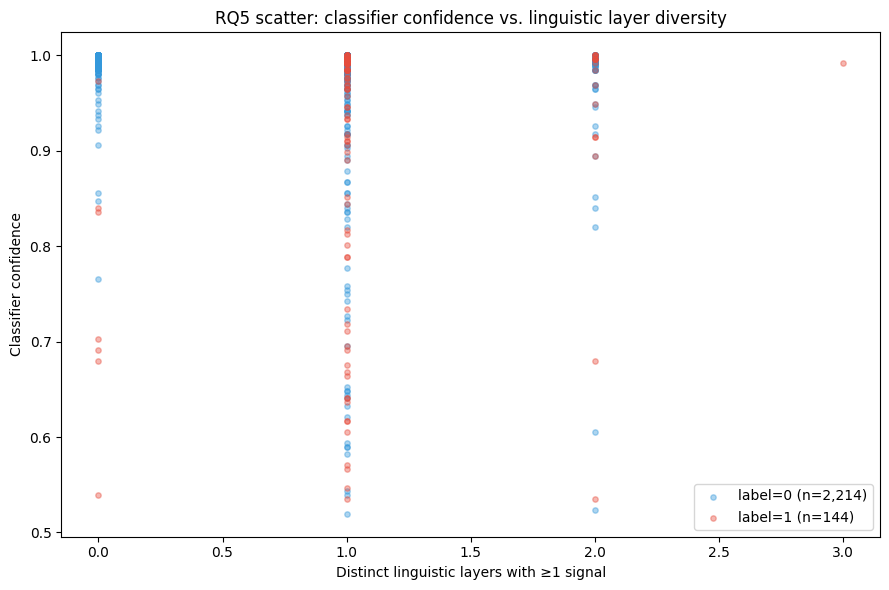

In [14]:
df_rq5_raw = q("""
    MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict)
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(s:Signal)
    WHERE s.layer IN ['lexical','morpho_syntactic','word_formation','rhetorical']
    WITH u, v, count(DISTINCT s.layer) AS layer_diversity
    RETURN v.label AS label,
           v.confidence AS confidence,
           layer_diversity,
           u.id AS tu_id
""")

if df_rq5_raw.empty:
    print('No ClassifierVerdict nodes yet. Run ClassifierAnnotator first.')
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    for label, grp in df_rq5_raw.groupby('label'):
        color = '#e74c3c' if label == 1 else '#3498db'
        ax.scatter(grp['layer_diversity'], grp['confidence'],
                   alpha=0.4, s=15, c=color,
                   label=f'label={label} (n={len(grp):,})')
    ax.set_xlabel('Distinct linguistic layers with ≥1 signal')
    ax.set_ylabel('Classifier confidence')
    ax.set_title('RQ5 scatter: classifier confidence vs. linguistic layer diversity')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5 (revised). RQ5 — Classifier false negatives: full origin + per-layer NK signals

Returns TextUnits where the classifier predicts **label=0** (no NK) but
≥ 2 independent linguistic layers disagree.

**Columns returned**

| Column | Content |
| --- | --- |
| `tu_id`, `text`, `position` | TextUnit identity |
| `tu_created_at` | TextUnit creation timestamp |
| `clf_confidence` | Classifier confidence on label=0 |
| `layer_count` | How many linguistic layers fired |
| `repo` | Repository full name |
| `parent_type` | Issue \| PullRequest \| Commit \| Comment |
| `parent_ref` | Issue/PR number, or first 8 chars of commit SHA |
| `author` | GitHub login of artefact author |
| `text_role` | title \| body \| commit_message \| comment_body |
| `lexical_markers` | List of `{rule_id, surface, lemma, category, polarity}` |
| `morph_signals` | List of `{category, subcategory, rule_id, surface}` |
| `word_formation_signals` | List of `{category, subcategory, rule_id, surface}` |
| `rhetorical_signals` | List of `{figure_id, family, subtype, surface}` |
| `n_lex`, `n_morph`, `n_wf`, `n_rhet` | Per-layer signal counts |

> **Cross-product note.** Multiple `OPTIONAL MATCH` clauses for different signal
> layers would multiply row counts before `collect()`. This query uses one
> `CALL {}` subquery per layer to keep the collections independent.

> **Comment parents.** `repo` is null when the TextUnit's parent is a `Comment`
> (Comments are not directly CONTAINED by a Repository). Filter with
> `df[df.repo.notna()]` if you want artefact-level units only.

In [ ]:
CYPHER_RQ5 = """
// RQ5 — Classifier false negatives
// TextUnits: classifier label=0 AND >= $min_layers linguistic layers firing.

MATCH (u:TextUnit)-[:CLASSIFIED_AS]->(v:ClassifierVerdict {label: 0})
MATCH (u)-[:HAS_SIGNAL]->(s_filter:Signal)
WHERE s_filter.layer IN ['lexical','morpho_syntactic','word_formation','rhetorical']
WITH u, v, count(DISTINCT s_filter.layer) AS layer_count
WHERE layer_count >= $min_layers

// ── Origin ────────────────────────────────────────────────────────────────
MATCH (parent)-[ht:HAS_TEXT]->(u)
OPTIONAL MATCH (repo:Repository)-[:CONTAINS]->(parent)
OPTIONAL MATCH (actor:Actor)-[:AUTHORED]->(parent)

// ── NK signals per layer (CALL {} avoids cross-product) ───────────────────
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sl:Signal {layer: 'lexical'})
    OPTIONAL MATCH (sl)-[:MATCHES_MARKER]->(m:LexicalMarker)
    RETURN collect(DISTINCT {
        rule_id:  sl.rule_id,
        surface:  sl.surface_form,
        lemma:    m.lemma,
        category: m.category,
        polarity: m.polarity
    }) AS lexical_markers
}
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sm:Signal {layer: 'morpho_syntactic'})
    RETURN collect(DISTINCT {
        category:    sm.category,
        subcategory: sm.subcategory,
        rule_id:     sm.rule_id,
        surface:     sm.surface_form
    }) AS morph_signals
}
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sw:Signal {layer: 'word_formation'})
    RETURN collect(DISTINCT {
        category:    sw.category,
        subcategory: sw.subcategory,
        rule_id:     sw.rule_id,
        surface:     sw.surface_form
    }) AS word_formation_signals
}
CALL {
    WITH u
    OPTIONAL MATCH (u)-[:HAS_SIGNAL]->(sr:Signal {layer: 'rhetorical'})
    OPTIONAL MATCH (sr)-[:INSTANTIATES]->(f:RhetoricalFigure)
    RETURN collect(DISTINCT {
        figure_id: f.figure_id,
        family:    f.family,
        subtype:   f.subtype,
        surface:   sr.surface_form
    }) AS rhetorical_signals
}

RETURN
    // Identity
    u.id              AS tu_id,
    u.text            AS text,
    u.position        AS position,
    u.created_at      AS tu_created_at,

    // Classifier
    v.confidence      AS clf_confidence,
    layer_count,

    // Origin
    coalesce(repo.full_name, '(comment)')  AS repo,
    labels(parent)[0]                      AS parent_type,
    CASE labels(parent)[0]
        WHEN 'Issue'       THEN toString(parent.number)
        WHEN 'PullRequest' THEN toString(parent.number)
        WHEN 'Commit'      THEN left(parent.sha, 8)
        ELSE null
    END                                    AS parent_ref,
    actor.login                            AS author,
    ht.role                                AS text_role,

    // NK signals — each layer in its own column
    lexical_markers,
    morph_signals,
    word_formation_signals,
    rhetorical_signals,

    // Flat counts for quick filtering
    size(lexical_markers)        AS n_lex,
    size(morph_signals)          AS n_morph,
    size(word_formation_signals) AS n_wf,
    size(rhetorical_signals)     AS n_rhet

ORDER BY layer_count DESC, clf_confidence DESC
LIMIT $limit
"""

df_fn = q(CYPHER_RQ5, min_layers=2, limit=50)
print(f"False negatives found: {len(df_fn)}")
df_fn[[
    'repo', 'parent_type', 'parent_ref', 'author', 'text_role',
    'tu_created_at', 'position', 'clf_confidence', 'layer_count',
    'n_lex', 'n_morph', 'n_wf', 'n_rhet', 'text'
]].head(20)

In [ ]:
# ── Flatten nested signal lists into readable columns ─────────────────────
# Each *_signals column is a list of dicts.  These helpers extract flat lists
# of the most useful fields for quick scanning.

def pick(lst, key):
    """Extract `key` from each dict in a list, dropping None values."""
    return [item[key] for item in (lst or []) if item.get(key) is not None]

if not df_fn.empty:
    df_fn['lex_lemmas']     = df_fn['lexical_markers'].apply(lambda x: pick(x, 'lemma'))
    df_fn['lex_polarities'] = df_fn['lexical_markers'].apply(lambda x: pick(x, 'polarity'))
    df_fn['morph_cats']     = df_fn['morph_signals'].apply(
                                  lambda x: list(dict.fromkeys(pick(x, 'category'))))
    df_fn['morph_subcats']  = df_fn['morph_signals'].apply(
                                  lambda x: list(dict.fromkeys(pick(x, 'subcategory'))))
    df_fn['rhet_families']  = df_fn['rhetorical_signals'].apply(lambda x: pick(x, 'family'))
    df_fn['rhet_subtypes']  = df_fn['rhetorical_signals'].apply(lambda x: pick(x, 'subtype'))
    df_fn['wf_rules']       = df_fn['word_formation_signals'].apply(lambda x: pick(x, 'rule_id'))

    display(df_fn[[
        'repo', 'parent_type', 'parent_ref', 'author', 'text_role', 'tu_created_at',
        'clf_confidence', 'layer_count',
        'lex_lemmas', 'lex_polarities',
        'morph_cats', 'morph_subcats',
        'wf_rules',
        'rhet_families', 'rhet_subtypes',
        'text'
    ]].head(20))

## 6. Signal layer co-occurrence matrix

Which layers tend to fire together? Relevant for RQ2 prototypical co-occurrences.

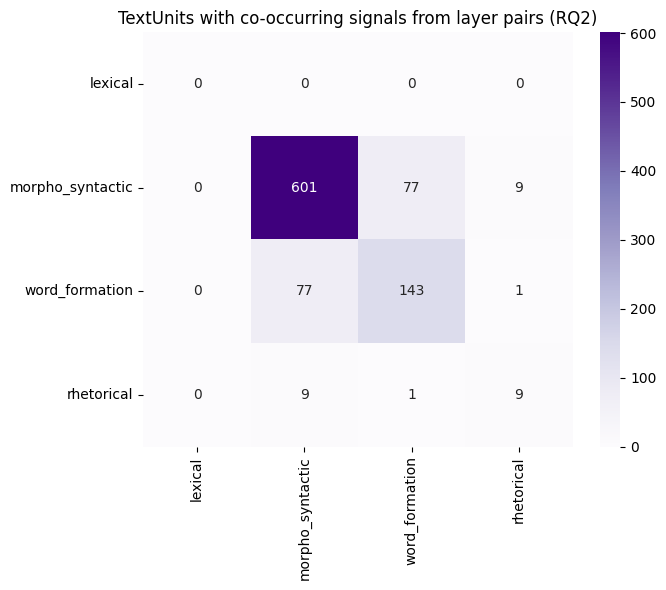

In [15]:
layers = ['lexical', 'morpho_syntactic', 'word_formation', 'rhetorical']

cooc = pd.DataFrame(0, index=layers, columns=layers)
for i, l1 in enumerate(layers):
    for l2 in layers[i:]:
        df_pair = q("""
            MATCH (u:TextUnit)-[:HAS_SIGNAL]->(s1:Signal {layer: $l1})
            MATCH (u)-[:HAS_SIGNAL]->(s2:Signal {layer: $l2})
            RETURN count(DISTINCT u) AS n
        """, l1=l1, l2=l2)
        n = int(df_pair['n'].iloc[0]) if not df_pair.empty else 0
        cooc.loc[l1, l2] = n
        cooc.loc[l2, l1] = n

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_title('TextUnits with co-occurring signals from layer pairs (RQ2)')
plt.tight_layout()
plt.show()

In [ ]:
driver.close()
print('Done.')